In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.datasets import fetch_california_housing
fth=fetch_california_housing()
df=pd.DataFrame(fth.data,columns=fth.feature_names)
df


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [3]:
df['price']=fth.target

In [4]:
df = df.sample(frac=0.20, random_state=1)

In [5]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]


In [6]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=1
)


In [7]:
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor()
model.fit(x_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [8]:
y_pred=model.predict(x_test)
y_pred

array([2.098  , 1.138  , 2.27   , 0.71   , 1.119  , 0.531  , 1.686  ,
       2.318  , 3.065  , 1.804  , 1.912  , 0.742  , 2.292  , 4.112  ,
       2.557  , 4.5    , 2.438  , 1.563  , 1.41   , 1.406  , 1.27   ,
       1.125  , 1.918  , 0.87   , 1.367  , 1.421  , 0.481  , 2.05   ,
       1.7    , 5.00001, 2.325  , 1.625  , 1.891  , 2.4    , 1.125  ,
       1.391  , 0.675  , 0.868  , 1.186  , 2.058  , 2.854  , 1.719  ,
       2.871  , 2.835  , 2.218  , 0.833  , 1.639  , 1.42   , 4.169  ,
       2.285  , 1.413  , 1.414  , 2.773  , 3.325  , 2.003  , 2.55   ,
       1.425  , 0.867  , 1.75   , 1.125  , 1.264  , 0.469  , 0.962  ,
       2.083  , 0.892  , 5.     , 1.133  , 2.17   , 2.866  , 2.003  ,
       0.806  , 1.597  , 2.218  , 0.637  , 1.118  , 0.975  , 0.929  ,
       1.732  , 3.     , 3.167  , 1.841  , 1.491  , 3.9    , 2.256  ,
       1.976  , 1.78   , 2.287  , 3.353  , 1.515  , 1.073  , 0.75   ,
       1.389  , 0.467  , 1.024  , 2.31   , 3.097  , 1.214  , 1.312  ,
       1.994  , 1.64

In [9]:
from sklearn.metrics import r2_score
r2_score(y_pred,y_test)

0.5657041126503222

In [10]:
# hyper parameter tuning

In [11]:
params= { 'criterion':["squared_error","absolute_error","friedman_mse","poisson"],
            'splitter':['best','random'],
            'max_depth':[1,2,3,4,10],
            'max_features':['sqrt','log2','auto']
           
           }

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
dtr=DecisionTreeRegressor()
model2=GridSearchCV(dtr,param_grid=params,cv=3,scoring='neg_mean_squared_error',verbose=3)
model2.fit(x_train,y_train)


Fitting 3 folds for each of 120 candidates, totalling 360 fits
[CV 1/3] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=best;, score=-0.972 total time=   0.0s
[CV 2/3] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=best;, score=-1.226 total time=   0.0s
[CV 3/3] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=best;, score=-1.179 total time=   0.0s
[CV 1/3] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=random;, score=-1.069 total time=   0.0s
[CV 2/3] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=random;, score=-1.306 total time=   0.0s
[CV 3/3] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=random;, score=-1.288 total time=   0.0s
[CV 1/3] END criterion=squared_error, max_depth=1, max_features=log2, splitter=best;, score=-0.972 total time=   0.0s
[CV 2/3] END criterion=squared_error, max_depth=1, max_features=log2, splitter=best;, score=-1.286 total 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['squared_error', 'absolute_error', ...], 'max_depth': [1, 2, ...], 'max_features': ['sqrt', 'log2', ...], 'splitter': ['best', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the 

In [13]:
model2.best_params_, model2.best_score_


({'criterion': 'friedman_mse',
  'max_depth': 10,
  'max_features': 'log2',
  'splitter': 'best'},
 np.float64(-0.6267533368200583))

In [14]:
model2.best_estimator_.fit(x_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'friedman_mse'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_

[Text(0.5880952897293547, 0.9545454545454546, 'x[0] <= 4.536\nfriedman_mse = 1.324\nsamples = 3302\nvalue = 2.035'),
 Text(0.28542461832061067, 0.8636363636363636, 'x[5] <= 2.299\nfriedman_mse = 0.779\nsamples = 2374\nvalue = 1.636'),
 Text(0.4367599540249827, 0.9090909090909092, 'True  '),
 Text(0.12771079111727968, 0.7727272727272727, 'x[1] <= 26.5\nfriedman_mse = 1.438\nsamples = 476\nvalue = 2.224'),
 Text(0.07009021512838307, 0.6818181818181818, 'x[6] <= 38.525\nfriedman_mse = 1.049\nsamples = 220\nvalue = 1.855'),
 Text(0.03183553088133241, 0.5909090909090909, 'x[4] <= 1254.0\nfriedman_mse = 1.054\nsamples = 187\nvalue = 2.0'),
 Text(0.017002081887578072, 0.5, 'x[3] <= 0.91\nfriedman_mse = 0.875\nsamples = 95\nvalue = 1.778'),
 Text(0.015614156835530881, 0.4090909090909091, 'friedman_mse = 0.0\nsamples = 1\nvalue = 4.75'),
 Text(0.01839000693962526, 0.4090909090909091, 'x[5] <= 1.515\nfriedman_mse = 0.789\nsamples = 94\nvalue = 1.746'),
 Text(0.009021512838306732, 0.3181818181818

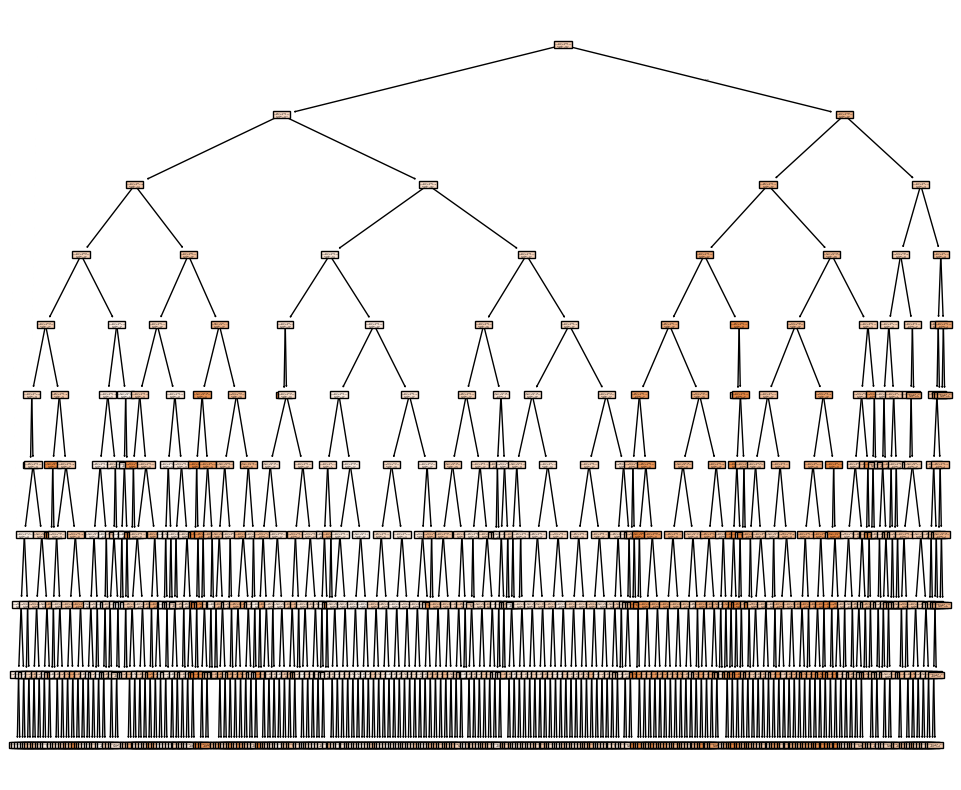

In [15]:
from sklearn import tree
plt.figure(figsize = (12, 10))
tree.plot_tree(model2.best_estimator_, filled=True)